# Exhaustive feature subset search - ExtraTrees
**Stage 1** : all subsets k=2..7 from 7 candidate features × 4 HP configs  
**Stage 2** : Optuna fine-tuning on top-5 subsets


In [1]:
!pip install optuna -q

In [2]:
import os, time, warnings
from itertools import chain, combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import optuna
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict

optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings("ignore")


## Configuration

In [ ]:
ON_KAGGLE = os.path.exists("/kaggle")

DATA_DIR = (
    "/kaggle/input/datasets/bolesawpaliwoda/aml-project-2/data"
    if ON_KAGGLE else "data"
)
from pathlib import Path
DATA_DIR = Path(DATA_DIR)

TRAIN_X = DATA_DIR / "processed" / "x_train_scaled_reduced_after_mi.csv"
TRAIN_Y = DATA_DIR / "y_train.txt"

CANDIDATES = ["V176", "V255", "V191", "V160", "V215", "V380", "V342"]

CV_FOLDS     = 5
RANDOM_STATE = 0
CAP          = 1000

FIXED_HP_CONFIGS = [
    dict(n_estimators=419, max_depth=6,  min_samples_split=7, min_samples_leaf=2,  criterion="gini",    class_weight="balanced"),
    dict(n_estimators=267, max_depth=5,  min_samples_split=6, min_samples_leaf=1,  criterion="entropy", class_weight=None),
    dict(n_estimators=158, max_depth=3,  min_samples_split=7, min_samples_leaf=3,  criterion="gini",    class_weight=None),
    dict(n_estimators=54,  max_depth=3,  min_samples_split=5, min_samples_leaf=5,  criterion="entropy", class_weight="balanced"),
]

TOP_N_OPTUNA  = 5
OPTUNA_TRIALS = 80

print(f"Environment : {'Kaggle' if ON_KAGGLE else 'local'}")
print(f"DATA_DIR    : {DATA_DIR}")
print(f"Candidates  : {CANDIDATES}")
print(f"Subsets k=2..7: {sum(1 for k in range(2,8) for _ in combinations(CANDIDATES,k))}")


Environment : Kaggle
DATA_DIR    : /kaggle/input/datasets/bolesawpaliwoda/aml-project-2/data
Candidates  : ['V176', 'V255', 'V191', 'V160', 'V215', 'V380', 'V342']
Subsets k=2..7: 120


## Helpers

In [4]:
def sweep_cutoff(y_true, p, n_vars, cap=CAP):
    order = np.argsort(-p)
    best_s, best_n = -np.inf, 0
    for n in range(1, min(cap, len(p)) + 1):
        idx = order[:n]
        tp  = int(np.sum(y_true[idx] == 1))
        s   = tp * 10 - (n - tp) * 5 - n_vars * 200
        if s > best_s:
            best_s, best_n = s, n
    if best_n == 0:
        return int(best_s), 0, 0.0, 0, 0
    tp_best  = int(np.sum(y_true[order[:best_n]] == 1))
    thr_best = float(p[order[best_n - 1]])
    return int(best_s), best_n, thr_best, tp_best, best_n - tp_best


def oof_score(X_arr, y, hp, n_vars):
    model = ExtraTreesClassifier(**hp, random_state=RANDOM_STATE, n_jobs=-1)
    skf   = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    p_oof = cross_val_predict(model, X_arr, y, cv=skf, method="predict_proba", n_jobs=1)[:, 1]
    return sweep_cutoff(y, p_oof, n_vars)


def all_subsets(elements, min_k=2, max_k=None):
    max_k = max_k or len(elements)
    return list(chain.from_iterable(combinations(elements, k) for k in range(min_k, max_k + 1)))


## Data

In [5]:
X_df = pd.read_csv(TRAIN_X)
y    = np.loadtxt(TRAIN_Y, skiprows=1).astype(int)
print(f"X_train {X_df.shape}   y positive rate {y.mean():.3f}")
assert all(c in X_df.columns for c in CANDIDATES), "Missing candidate columns!"


X_train (5000, 493)   y positive rate 0.498


## Stage 1 - exhaustive search

In [6]:
subsets = all_subsets(CANDIDATES)
rows    = []
t0      = time.time()

for i, subset in enumerate(subsets):
    feats = list(subset)
    k     = len(feats)
    X_arr = X_df[feats].to_numpy()
    best  = None

    for hp in FIXED_HP_CONFIGS:
        score, N, thr, tp, fp = oof_score(X_arr, y, hp, n_vars=k)
        if best is None or score > best["score"]:
            best = dict(score=score, k=k, N=N, thr=thr, tp=tp, fp=fp, features=feats, hp=hp)

    rows.append(best)
    eta = (time.time() - t0) / (i + 1) * (len(subsets) - i - 1)
    print(f"[{i+1:3d}/{len(subsets)}] k={k}  {feats}  score={best['score']}  N={best['N']}  TP={best['tp']}  ETA {eta/60:.1f}min")

results1 = pd.DataFrame(rows).sort_values("score", ascending=False).reset_index(drop=True)
print(f"\nStage 1 done: {(time.time()-t0)/60:.1f} min")


[  1/120] k=2  ['V176', 'V255']  score=4950  N=991  TP=687  ETA 29.8min
[  2/120] k=2  ['V176', 'V191']  score=4920  N=1000  TP=688  ETA 29.6min
[  3/120] k=2  ['V176', 'V160']  score=4845  N=1000  TP=683  ETA 29.3min
[  4/120] k=2  ['V176', 'V215']  score=4545  N=1000  TP=663  ETA 29.1min
[  5/120] k=2  ['V176', 'V380']  score=4925  N=999  TP=688  ETA 29.4min
[  6/120] k=2  ['V176', 'V342']  score=4730  N=999  TP=675  ETA 29.1min
[  7/120] k=2  ['V255', 'V191']  score=4710  N=1000  TP=674  ETA 29.2min
[  8/120] k=2  ['V255', 'V160']  score=4920  N=1000  TP=688  ETA 28.8min
[  9/120] k=2  ['V255', 'V215']  score=4815  N=1000  TP=681  ETA 28.5min
[ 10/120] k=2  ['V255', 'V380']  score=4905  N=1000  TP=687  ETA 28.2min
[ 11/120] k=2  ['V255', 'V342']  score=4715  N=999  TP=674  ETA 27.8min
[ 12/120] k=2  ['V191', 'V160']  score=4755  N=997  TP=676  ETA 27.4min
[ 13/120] k=2  ['V191', 'V215']  score=4635  N=1000  TP=669  ETA 27.3min
[ 14/120] k=2  ['V191', 'V380']  score=4770  N=997  TP=6

### Results

In [7]:
best_per_k = results1.groupby("k").first().reset_index()
best_per_k["var_cost"]   = best_per_k["k"] * 200
best_per_k["precision@N"] = (best_per_k["tp"] / best_per_k["N"]).round(3)
display(best_per_k[["k", "score", "N", "tp", "fp", "var_cost", "precision@N", "features"]]
        .style.highlight_max(subset=["score"], color="#c6efce"))


,k,score,N,tp,fp,var_cost,precision@N,features
0,2,4950,991,687,304,400,0.693000,"['V176', 'V255']"
1,3,5335,1000,729,271,600,0.729000,"['V176', 'V255', 'V342']"
2,4,5400,998,746,252,800,0.747000,"['V255', 'V160', 'V215', 'V380']"
3,5,5595,1000,773,227,1000,0.773000,"['V255', 'V191', 'V215', 'V380', 'V342']"
4,6,5580,999,785,214,1200,0.786000,"['V176', 'V255', 'V191', 'V160', 'V380', 'V342']"
5,7,5485,993,790,203,1400,0.796000,"['V176', 'V255', 'V191', 'V160', 'V215', 'V380', 'V342']"


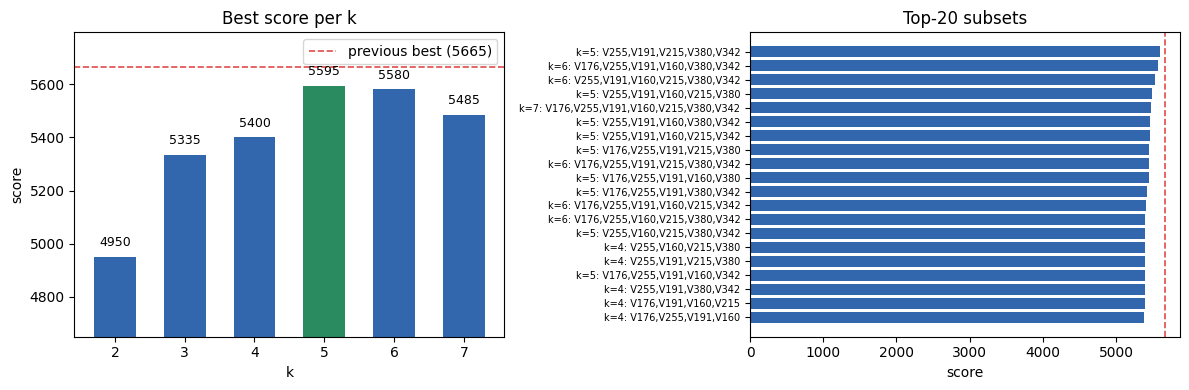

Global best (Stage 1): score=5595  k=5  features=['V255', 'V191', 'V215', 'V380', 'V342']


In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

k_vals = best_per_k["k"].tolist()
scores = best_per_k["score"].tolist()
colors = ["#2a8a60" if s == max(scores) else "#3266ad" for s in scores]
ax1.bar(k_vals, scores, color=colors, width=0.6)
ax1.axhline(5665, color="#e24b4a", linestyle="--", lw=1.2, label="previous best (5665)")
ax1.set_xlabel("k"); ax1.set_ylabel("score"); ax1.set_title("Best score per k")
ax1.set_ylim(min(scores) - 300, max(scores) + 200); ax1.legend()
for k, s in zip(k_vals, scores):
    ax1.text(k, s + 40, str(s), ha="center", fontsize=9)

top20 = results1.head(20).copy()
top20["label"] = top20.apply(lambda r: f"k={r['k']}: {','.join(r['features'])}", axis=1)
yp = range(len(top20))
ax2.barh(list(yp), top20["score"].tolist(), color="#3266ad")
ax2.axvline(5665, color="#e24b4a", linestyle="--", lw=1.2)
ax2.set_yticks(list(yp)); ax2.set_yticklabels(top20["label"].tolist(), fontsize=7)
ax2.invert_yaxis(); ax2.set_xlabel("score"); ax2.set_title("Top-20 subsets")

plt.tight_layout(); plt.show()
print(f"Global best (Stage 1): score={results1.iloc[0]['score']}  k={results1.iloc[0]['k']}  features={results1.iloc[0]['features']}")


In [9]:
results1.to_csv("exhaustive_stage1.csv", index=False)
print("Saved exhaustive_stage1.csv")

Saved exhaustive_stage1.csv


## Stage 2 - Optuna HP fine-tuning

In [ ]:
optuna_rows = []
t0 = time.time()

for rank, (_, row) in enumerate(results1.head(TOP_N_OPTUNA).iterrows(), 1):
    feats = row["features"]
    k     = len(feats)
    X_arr = X_df[feats].to_numpy()
    print(f"\n[{rank}/{TOP_N_OPTUNA}] k={k}  {feats}  baseline={row['score']}")

    def objective(trial):
        hp = dict(
            n_estimators      = trial.suggest_int("n_estimators", 50, 600),
            max_depth         = trial.suggest_int("max_depth", 2, 12),
            min_samples_split = trial.suggest_int("min_samples_split", 2, 12),
            min_samples_leaf  = trial.suggest_int("min_samples_leaf", 1, 10),
            criterion         = trial.suggest_categorical("criterion", ["gini", "entropy"]),
            class_weight      = trial.suggest_categorical("class_weight", ["balanced", None]),
        )
        score, *_ = oof_score(X_arr, y, hp, n_vars=k)
        return score

    study = optuna.create_study(direction="maximize",
                                sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
    for hp in FIXED_HP_CONFIGS:
        study.enqueue_trial({
            "n_estimators": hp["n_estimators"], "max_depth": hp["max_depth"] or 8,
            "min_samples_split": hp["min_samples_split"], "min_samples_leaf": hp["min_samples_leaf"],
            "criterion": hp["criterion"], "class_weight": hp["class_weight"],
        })
    study.optimize(objective, n_trials=OPTUNA_TRIALS, show_progress_bar=True)

    s, N, thr, tp, fp = oof_score(X_arr, y, study.best_params, n_vars=k)
    print(f"  -> Optuna: {s}  ({s - row['score']:+d} vs baseline)  N={N}  TP={tp}")
    optuna_rows.append(dict(score=s, k=k, N=N, thr=thr, tp=tp, fp=fp,
                            features=feats, hp=study.best_params))

results2 = pd.DataFrame(optuna_rows).sort_values("score", ascending=False).reset_index(drop=True)
print(f"\nStage 2 done: {(time.time()-t0)/60:.1f} min")


In [11]:
results2.to_csv("exhaustive_stage2.csv", index=False)
print("Saved exhaustive_stage2.csv")

Saved exhaustive_stage2.csv


## Final results

In [12]:
all_rows = (
    [dict(stage=1, **{k: r[k] for k in ["score","k","N","tp","fp","features","hp"]})
     for _, r in results1.iterrows()] +
    [dict(stage=2, **{k: r[k] for k in ["score","k","N","tp","fp","features","hp"]})
     for _, r in results2.iterrows()]
)
final = pd.DataFrame(all_rows).sort_values("score", ascending=False).reset_index(drop=True)
best  = final.iloc[0]

print("=" * 50)
print(f"BEST RESULT")
print(f"  score    : {best['score']}")
print(f"  k        : {best['k']}  (var cost: {best['k']*200})")
print(f"  features : {best['features']}")
print(f"  N        : {best['N']}  TP={best['tp']}  FP={best['fp']}")
print(f"  prec@N   : {best['tp']/best['N']:.1%}")
print(f"  stage    : {best['stage']}")
print(f"  HP       : {best['hp']}")
print("=" * 50)

display(final.head(10)[["stage","score","k","N","tp","fp","features"]]
        .assign(**{"prec@N": lambda d: (d.tp/d.N).map("{:.1%}".format)})
        .style.highlight_max(subset=["score"], color="#c6efce"))


BEST RESULT
  score    : 5685
  k        : 6  (var cost: 1200)
  features : ['V176', 'V255', 'V191', 'V160', 'V380', 'V342']
  N        : 999  TP=792  FP=207
  prec@N   : 79.3%
  stage    : 2
  HP       : {'n_estimators': 214, 'max_depth': 12, 'min_samples_split': 9, 'min_samples_leaf': 8, 'criterion': 'gini', 'class_weight': 'balanced'}


,stage,score,k,N,tp,fp,features,prec@N
0,2,5685,6,999,792,207,"['V176', 'V255', 'V191', 'V160', 'V380', 'V342']",79.3%
1,2,5630,5,999,775,224,"['V255', 'V191', 'V215', 'V380', 'V342']",77.6%
2,1,5595,5,1000,773,227,"['V255', 'V191', 'V215', 'V380', 'V342']",77.3%
3,1,5580,6,999,785,214,"['V176', 'V255', 'V191', 'V160', 'V380', 'V342']",78.6%
4,2,5575,7,999,798,201,"['V176', 'V255', 'V191', 'V160', 'V215', 'V380', 'V342']",79.9%
5,2,5575,6,1000,785,215,"['V255', 'V191', 'V160', 'V215', 'V380', 'V342']",78.5%
6,2,5565,5,1000,771,229,"['V255', 'V191', 'V160', 'V215', 'V380']",77.1%
7,1,5530,6,1000,782,218,"['V255', 'V191', 'V160', 'V215', 'V380', 'V342']",78.2%
8,1,5490,5,1000,766,234,"['V255', 'V191', 'V160', 'V215', 'V380']",76.6%
9,1,5485,7,993,790,203,"['V176', 'V255', 'V191', 'V160', 'V215', 'V380', 'V342']",79.6%


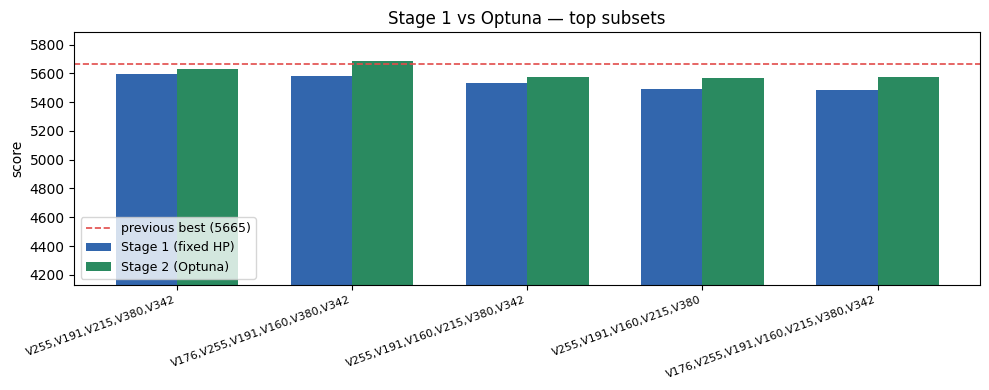

In [13]:
stage1_scores = {tuple(r["features"]): r["score"] for _, r in results1.head(TOP_N_OPTUNA).iterrows()}
stage2_scores = {tuple(r["features"]): r["score"] for _, r in results2.iterrows()}
keys = list(stage1_scores.keys())

comp = pd.DataFrame({
    "features": keys,
    "stage1":   [stage1_scores[k] for k in keys],
    "stage2":   [stage2_scores.get(k, stage1_scores[k]) for k in keys],
})
comp["label"] = comp["features"].apply(lambda f: ",".join(f))

x, w = range(len(comp)), 0.35
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar([i - w/2 for i in x], comp["stage1"], width=w, label="Stage 1 (fixed HP)", color="#3266ad")
ax.bar([i + w/2 for i in x], comp["stage2"], width=w, label="Stage 2 (Optuna)",   color="#2a8a60")
ax.axhline(5665, color="#e24b4a", linestyle="--", lw=1.2, label="previous best (5665)")
ax.set_xticks(list(x))
ax.set_xticklabels(comp["label"].tolist(), rotation=20, ha="right", fontsize=8)
ax.set_ylabel("score")
ax.set_title("Stage 1 vs Optuna — top subsets")
ax.legend(fontsize=9)
ax.set_ylim(final["score"].min() - 200, final["score"].max() + 200)
plt.tight_layout()
plt.show()


In [14]:
final.to_csv("exhaustive_final.csv", index=False)

best = final.iloc[0]
import json
with open("best_config.json", "w") as f:
    json.dump({
        "score":    int(best["score"]),
        "k":        int(best["k"]),
        "features": best["features"],
        "N":        int(best["N"]),
        "tp":       int(best["tp"]),
        "fp":       int(best["fp"]),
        "stage":    int(best["stage"]),
        "hp":       best["hp"],
    }, f, indent=2)

print("Saved exhaustive_final.csv + best_config.json")

Saved exhaustive_final.csv + best_config.json
